In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings("ignore")

onset_time = {"HS44":0,"HS45":0,"HS47":0,"HS48":0,"HS50":0,"HS54":0,"HS71":0,"HS73":0,"HS76":0,"HS78":0}
brain_path = path+"elecs/brain2D/"
perm_path = path+'perm_beta1/'
HS_list = [45,47,48,50,54,71,73,76,78]

color_set = {"syllable":"k","relPitch":(247/255,121/255,98/255),
             "larynx":'orange',
#              "lower_incisor":(148/255,148/255,148/255),
             "lower_incisor":'g',
             "upper_lip":(227/255,67/255,95/255),
             "lower_lip":(243/255,216/255,109/255),
             "tongue_tip":(104/255,181/255,113/255),
             "tongue_body":(177/255,84/255,153/255),
             "tongue_dorsum":'b',
            'consonantal_place':'r', 
             'consonantal_manner':'b', 
             'vowel_place':'g',
            'intensity':'b', 
             'absPitch':'b', 
             'f1':'b', 
             'f2':'b', 
             'peakRate':'b',
            'bilabial':'r',
             'alveolar':'g',
             'velar':'b',
             'back tongue':'orange',
             'jaw':(148/255,148/255,148/255),
             'lips':'r', 
             'tongue':'b',
             'mandibular':'g',
             "lip_AKTs":'r', 
             "tongue_AKTs":'b',
             
            }

fs = 10
ds_a = -40
ds_p = 41
delays = np.arange(ds_a, ds_p)

In [2]:
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta1': (12, 24),
    'beta2': (24, 40),
    'low_gamma': (40, 70),
    'high_gamma': (70, 150)
}

band = 'high_gamma'

In [3]:
feature_pool = {}
ex_features = {}

feature_pool["small_trace_model"] = ["lower_incisor","lip_AKTs","tongue_AKTs","larynx"]
ex_features["small_trace_model"] = ["lower_incisor","lip_AKTs","tongue_AKTs","larynx"]

feature_pool["trace_model"] = ["lower_incisor","upper_lip","lower_lip","tongue_tip","tongue_body","tongue_dorsum","larynx"]
ex_features["trace_model"] = ["lower_incisor","upper_lip","lower_lip","tongue_tip","tongue_body","tongue_dorsum","larynx"]

# Ext. Fig. 3o

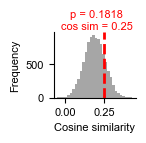

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# Define the analysis parameters.
# =====================================================

model = "trace_model"
sta = "delta_r2"

feature_names = feature_pool[model]

# =====================================================
# Plot exclusively from the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 3o"
)

perm_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 3o permutation"
)

# Reconstruct the matrices.

o_arr = source_df[
    [f"SA_specific_{f}" for f in feature_names]
].values

c_arr = source_df[
    [f"SI_specific_{f}" for f in feature_names]
].values

perm_distribution = perm_df[
    "Permutation cosine similarity"
].values

cosine_sim = cosine_similarity(
    o_arr.reshape(1,-1),
    c_arr.reshape(1,-1)
)[0,0]

p_value = (
    perm_distribution >= cosine_sim
).mean()

# =====================================================
# Create the plot.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(1.5,1.5))

ax.hist(
    perm_distribution,
    bins=30,
    color="gray",
    alpha=0.7
)

ax.axvline(
    cosine_sim,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")


if p_value < 0.0001:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1, f'p < 0.0001\ncos sim = {cosine_sim:.2f}', color='red',ha='right')
else:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1.05, f'p = {p_value:.4f}\ncos sim = {cosine_sim:.2f}', color='red',ha='center')

plt.tight_layout()

plt.savefig(
    clean_data_path+
    "/figures_R3/Ext. Fig. 3o.pdf",
    dpi=300,
    transparent=True
)

plt.show()

['L', 'TT', 'TB', 'TD', 'LL', 'LI', 'UL']


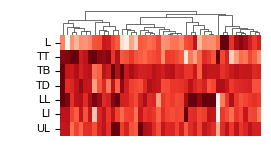

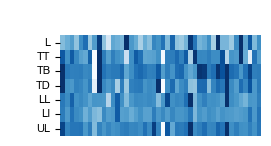

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# =====================================================
# Define the analysis parameters.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

model = "trace_model"

vmin = 0
vmax = 0.8
# cmap = "Purples"

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df_SA = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 3r"
)

source_df_SI = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 3s"
)

# =====================================================
# Recover the matrices from the tabular data.
# =====================================================

o_arr = source_df_SA.values
c_arr = source_df_SI.values

# =====================================================
# Define the feature labels.
# =====================================================

akt_map_dict = {
    "lower_incisor": "LI",
    "upper_lip": "UL",
    "lower_lip": "LL",
    "tongue_tip": "TT",
    "tongue_body": "TB",
    "tongue_dorsum": "TD",
    "larynx": "L"
}

labels = [
    akt_map_dict.get(i, i)
    for i in feature_pool[model]
]

# =====================================================
# Perform hierarchical clustering.
# Cluster the electrodes while preserving the feature order.
# =====================================================

col_linkage = linkage(
    pdist(o_arr),
    method="ward"
)

row_linkage = linkage(
    pdist(o_arr.T),
    method="ward"
)

col_order = dendrogram(
    col_linkage,
    no_plot=True
)["leaves"]

row_order = dendrogram(
    row_linkage,
    no_plot=True
)["leaves"]

o_arr_clustered = o_arr[np.ix_(col_order, row_order)]
c_arr_clustered = c_arr[np.ix_(col_order, row_order)]

o_arr_clustered = o_arr_clustered.T
c_arr_clustered = c_arr_clustered.T

labels_clustered = [labels[i] for i in row_order]
print(labels_clustered)

# =====================================================
# Plot SA_specific for Fig. 2h.
# =====================================================

g = sns.clustermap(
    o_arr_clustered,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=True,
    method="ward",
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Ext. Fig. 3r.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Plot SI_specific for Fig. 2i.
# Reuse the electrode order from SA_shared.
# =====================================================

g = sns.clustermap(
    c_arr_clustered,
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=False,
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Ext. Fig. 3s.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()